# Homicidios en los departamentos de Colombia durante 2025

## Evaluación grupal 1

Integrantes:
- Bautista Janampa Jose_20220430
- Saldaña Ruiz Maria Milagros_20241445
- Diaz Sulca Andrea Ariana_20245499


En este trabajo se analiza la distribución departamental de los homicidios registrados en Colombia durante 2025. La variable principal es `homicidios_2025` y la población proyectada para el mismo año se utiliza como referencia para construir una tasa comparable entre departamentos.

Se elaboran los tres mapas temáticos solicitados: mapa de densidad de puntos (DDM), mapa de símbolos proporcionales (PSM) y mapa coroplético. Los dos primeros representan cantidades absolutas. La coropleta responde una pregunta distinta, pues muestra los homicidios por cada 100 000 habitantes.

El CSV de homicidios fue preparado sumando las categorías de la fuente policial cuyo nombre comienza con “Homicidio”. Por ello incluye homicidio intencional y homicidio por tránsito vehicular. Esta definición debe conservarse al interpretar los resultados.

## Preparación del entorno

El cuaderno sigue la estructura de la evaluación individual y puede ejecutarse tanto en VS Code, donde fue realizado inicialmente este trabajo, como en Google Colab. La primera celda instala únicamente las bibliotecas que podrían faltar. Después se importan las herramientas utilizadas en la lectura, revisión y representación de los datos.

In [4]:
%%capture
%pip install -q geopandas mapclassify pyogrio

In [5]:
from pathlib import Path
from tempfile import TemporaryDirectory
from urllib.request import urlretrieve
import re
import unicodedata
import geopandas as gpd
import mapclassify
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

## Archivos de trabajo

Los tres archivos se leen desde el repositorio de GitHub. De esta forma, el análisis no depende de una ruta local como `D:/...` y puede reproducirse en otra computadora. Los CSV se leen directamente y el GeoPackage se descarga temporalmente porque este formato necesita acceso binario para consultar sus capas.

In [6]:
repo_raw = (
    "https://raw.githubusercontent.com/"
    "Jose-Bautista-gnss/Evaluacion_Grupal_1/main/data/"
)

gpkg_url = repo_raw + "departamentos_colombia.gpkg"
homicidios_url = repo_raw + "homicidios_2025.csv"
poblacion_url = repo_raw + "poblacion_2025.csv"

temporary_directory = TemporaryDirectory()
gpkg_path = Path(temporary_directory.name) / "departamentos_colombia.gpkg"
urlretrieve(gpkg_url, gpkg_path)

print("GeoPackage descargado desde GitHub.")

GeoPackage descargado desde GitHub.


Antes de leer las geometrías se revisan las capas del GeoPackage. El archivo actual contiene la capa `departamentos`, que es la utilizada en todo el trabajo.

In [7]:
layers = gpd.list_layers(gpkg_path)
layers

,name,geometry_type
0,departamentos,MultiPolygon


In [8]:
assert "departamentos" in layers["name"].tolist(), (
    "No se encontró la capa 'departamentos' en el GeoPackage."
)

departments_raw = gpd.read_file(
    gpkg_path,
    layer="departamentos"
)

departments_raw.head()

,DEP_NOMBRE,CAPITAL,geometry
0,MAGDALENA,SANTA MARTA,"MULTIPOLYGON (((-73.57985 11.26166, -73.57388 ..."
1,MAGDALENA,SANTA MARTA,"MULTIPOLYGON (((-74.13781 11.32975, -74.13774 ..."
2,ATLANTICO,BARRANQUILLA,"MULTIPOLYGON (((-75.23944 10.79562, -75.2372 1..."
3,CESAR,VALLEDUPAR,"MULTIPOLYGON (((-73.45995 10.86709, -73.45333 ..."
4,BOLIVAR,CARTAGENA,"MULTIPOLYGON (((-75.51861 10.42236, -75.51705 ..."


La capa está en WGS 84 (`EPSG:4326`). También se revisa su estructura porque el archivo contiene varias geometrías para algunos departamentos insulares o costeros; antes de unir los indicadores será necesario agruparlas.

In [9]:
departments_raw.info()
print("CRS:", departments_raw.crs)
print("Geometrías originales:", len(departments_raw))
print("Nombres diferentes:", departments_raw["DEP_NOMBRE"].nunique(dropna=True))
print("Registros sin nombre:", departments_raw["DEP_NOMBRE"].isna().sum())

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 223 entries, 0 to 222
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   DEP_NOMBRE  215 non-null    str     
 1   CAPITAL     215 non-null    str     
 2   geometry    223 non-null    geometry
dtypes: geometry(1), str(2)
memory usage: 5.4 KB
CRS: EPSG:4326
Geometrías originales: 223
Nombres diferentes: 31
Registros sin nombre: 8


Los CSV reúnen los indicadores ya procesados por departamento. Se leen sus primeras filas y se comprueba que tengan las columnas necesarias.

In [10]:
homicides = pd.read_csv(homicidios_url, encoding="utf-8-sig")
population = pd.read_csv(poblacion_url, encoding="utf-8-sig")

display(homicides.head())
display(population.head())

,departamento,homicidios_2025
0,AMAZONAS,18
1,ANTIOQUIA,2980
2,ARAUCA,182
3,ATLÁNTICO,1113
4,BOGOTA,1795


,departamento,poblacion_2025
0,Amazonas,85057
1,Antioquia,6928372
2,Arauca,279191
3,Atlántico,2865034
4,Bogotá,7942867


In [11]:
required_homicides = {"departamento", "homicidios_2025"}
required_population = {"departamento", "poblacion_2025"}

assert required_homicides.issubset(homicides.columns), (
    f"Faltan columnas en homicidios: {required_homicides - set(homicides.columns)}"
)
assert required_population.issubset(population.columns), (
    f"Faltan columnas en población: {required_population - set(population.columns)}"
)

# El CSV de población conserva una fila nacional llamada Total.
# Se retira porque el análisis necesita solamente unidades territoriales.
population = population[
    population["departamento"].str.strip().str.upper() != "TOTAL"
].copy()

homicides["homicidios_2025"] = pd.to_numeric(
    homicides["homicidios_2025"], errors="raise"
)
population["poblacion_2025"] = pd.to_numeric(
    population["poblacion_2025"], errors="raise"
)

data_review = pd.DataFrame({
    "tabla": ["Homicidios", "Población"],
    "filas": [len(homicides), len(population)],
    "duplicados": [
        homicides["departamento"].duplicated().sum(),
        population["departamento"].duplicated().sum()
    ],
    "valores_faltantes": [
        homicides[list(required_homicides)].isna().sum().sum(),
        population[list(required_population)].isna().sum().sum()
    ]
})

print("Homicidios registrados:", f"{homicides['homicidios_2025'].sum():,.0f}")
print("Población proyectada:", f"{population['poblacion_2025'].sum():,.0f}")
data_review

Homicidios registrados: 21,597
Población proyectada: 53,057,212


,tabla,filas,duplicados,valores_faltantes
0,Homicidios,33,0,0
1,Población,33,0,0


## Preparación de los nombres y las geometrías

Los tres archivos escriben algunos departamentos de manera diferente. Por ejemplo, el mapa usa `NORTESAN`, mientras que los CSV utilizan `Norte de Santander`; también aparecen diferencias en tildes y mayúsculas. Se crea una llave normalizada para unir sin modificar los nombres originales.

La normalización no utiliza coincidencia difusa automática. En un conjunto de solo 33 unidades es más seguro revisar y corregir explícitamente los pocos casos conocidos.

In [12]:
def normalize_department(value):
    if pd.isna(value):
        return pd.NA

    text = str(value).strip().upper()
    text = unicodedata.normalize("NFKD", text)
    text = "".join(char for char in text if not unicodedata.combining(char))
    text = re.sub(r"[^A-Z0-9 ]", " ", text)
    return re.sub(r"\s+", " ", text).strip()


shape_changes = {
    "NORTESAN": "NORTE DE SANTANDER"
}

csv_changes = {
    "GUAJIRA": "LA GUAJIRA",
    "VALLE": "VALLE DEL CAUCA",
    "SAN ANDRES": "SAN ANDRES Y PROVIDENCIA"
}

departments_raw["departamento_clave"] = (
    departments_raw["DEP_NOMBRE"]
    .map(normalize_department)
    .replace(shape_changes)
)
homicides["departamento_clave"] = (
    homicides["departamento"]
    .map(normalize_department)
    .replace(csv_changes)
)
population["departamento_clave"] = (
    population["departamento"]
    .map(normalize_department)
)

departments_raw[["DEP_NOMBRE", "departamento_clave"]].drop_duplicates().head(10)

,DEP_NOMBRE,departamento_clave
0,MAGDALENA,MAGDALENA
2,ATLANTICO,ATLANTICO
3,CESAR,CESAR
4,BOLIVAR,BOLIVAR
13,SUCRE,SUCRE
38,CORDOBA,CORDOBA
41,NORTESAN,NORTE DE SANTANDER
43,ANTIOQUIA,ANTIOQUIA
44,CHOCO,CHOCO
47,SANTANDER,SANTANDER


El GeoPackage contiene 223 polígonos, pero varios pertenecen al mismo departamento. Se eliminan únicamente los fragmentos sin nombre, se reparan las geometrías y se aplica `dissolve()` para obtener una geometría por departamento.

In [13]:
departments_clean = departments_raw.dropna(
    subset=["departamento_clave"]
).copy()

departments_clean = departments_clean[
    ~departments_clean.geometry.is_empty
].copy()
departments_clean["geometry"] = departments_clean.geometry.make_valid()

departments = departments_clean.dissolve(
    by="departamento_clave",
    as_index=False
)[["departamento_clave", "geometry"]]

print("Geometrías después de agrupar:", len(departments))
departments.head()

Geometrías después de agrupar: 31


,departamento_clave,geometry
0,AMAZONAS,"POLYGON ((-71.31395 0.10849, -71.31299 0.10809..."
1,ANTIOQUIA,"MULTIPOLYGON (((-76.40825 8.85689, -76.39429 8..."
2,ARAUCA,"POLYGON ((-71.95778 7.01592, -71.95409 7.01646..."
3,ATLANTICO,"POLYGON ((-75.23944 10.79562, -75.2372 10.7952..."
4,BOLIVAR,"MULTIPOLYGON (((-75.49424 10.41331, -75.48496 ..."


Primero se unen las dos tablas de indicadores. La validación `one_to_one` comprueba que cada departamento aparezca una sola vez en ambos CSV.

In [14]:
indicators = population[
    ["departamento_clave", "departamento", "poblacion_2025"]
].merge(
    homicides[["departamento_clave", "homicidios_2025"]],
    on="departamento_clave",
    how="outer",
    validate="one_to_one",
    indicator=True
)

assert (indicators["_merge"] == "both").all(), (
    "Existen departamentos que no coinciden entre los dos CSV."
)
indicators.drop(columns="_merge", inplace=True)

indicators.info()

<class 'pandas.DataFrame'>
RangeIndex: 33 entries, 0 to 32
Data columns (total 4 columns):
 #   Column              Non-Null Count  Dtype
---  ------              --------------  -----
 0   departamento_clave  33 non-null     str  
 1   departamento        33 non-null     str  
 2   poblacion_2025      33 non-null     int64
 3   homicidios_2025     33 non-null     int64
dtypes: int64(2), str(2)
memory usage: 1.2 KB


## Revisión de la unión espacial

Antes de crear los mapas se comparan las llaves. Esta revisión evita que una unidad territorial desaparezca silenciosamente durante el `merge`.

In [15]:
only_data = sorted(
    set(indicators["departamento_clave"])
    - set(departments["departamento_clave"])
)
only_map = sorted(
    set(departments["departamento_clave"])
    - set(indicators["departamento_clave"])
)

print("Con datos pero sin geometría:", only_data)
print("Con geometría pero sin datos:", only_map)

Con datos pero sin geometría: ['BOGOTA', 'SAN ANDRES Y PROVIDENCIA']
Con geometría pero sin datos: []


La auditoría muestra una limitación del GeoPackage disponible: no contiene polígonos identificados para Bogotá ni para San Andrés y Providencia. Sus registros permanecen en la tabla de indicadores, pero no se inventan geometrías para incorporarlos al mapa. Con el archivo actual, las representaciones espaciales incluyen 31 unidades. Si se reemplaza el GeoPackage por uno que contenga esas geometrías y conserve nombres equivalentes, el mismo flujo podrá incorporarlas.

In [16]:
map_and_data = departments.merge(
    indicators,
    on="departamento_clave",
    how="left",
    validate="one_to_one"
)

merge_review = pd.Series({
    "unidades_en_el_mapa": len(map_and_data),
    "homicidios_faltantes": map_and_data["homicidios_2025"].isna().sum(),
    "poblacion_faltante": map_and_data["poblacion_2025"].isna().sum(),
    "geometrias_invalidas": (~map_and_data.geometry.is_valid).sum(),
    "geometrias_vacias": map_and_data.geometry.is_empty.sum()
})

assert map_and_data[["homicidios_2025", "poblacion_2025"]].notna().all().all()
merge_review

unidades_en_el_mapa     31
homicidios_faltantes     0
poblacion_faltante       0
geometrias_invalidas     0
geometrias_vacias        0
dtype: int64

Para los tres mapas se utiliza `EPSG:9377`, correspondiente a MAGNA-SIRGAS 2018 / Origen-Nacional. Trabajar en metros evita hacer el muestreo de puntos y la ubicación de símbolos directamente sobre coordenadas angulares.

In [17]:
colombia_9377 = map_and_data.to_crs(9377)

minx, miny, maxx, maxy = colombia_9377.total_bounds
x_margin = (maxx - minx) * 0.04
y_margin = (maxy - miny) * 0.04
x_limits = (minx - x_margin, maxx + x_margin)
y_limits = (miny - y_margin, maxy + y_margin)

colombia_9377.crs

<Projected CRS: EPSG:9377>
Name: MAGNA-SIRGAS 2018 / Origen-Nacional
Axis Info [cartesian]:
- N[north]: Northing (metre)
- E[east]: Easting (metre)
Area of Use:
- name: Colombia - onshore and offshore. Includes San Andres y Providencia, Malpelo Islands, Roncador Bank, Serrana Bank and Serranilla Bank.
- bounds: (-84.77, -4.23, -66.87, 15.51)
Coordinate Operation:
- name: Colombia Transverse Mercator
- method: Transverse Mercator
Datum: Marco Geocentrico Nacional de Referencia 2018
- Ellipsoid: GRS 1980
- Prime Meridian: Greenwich

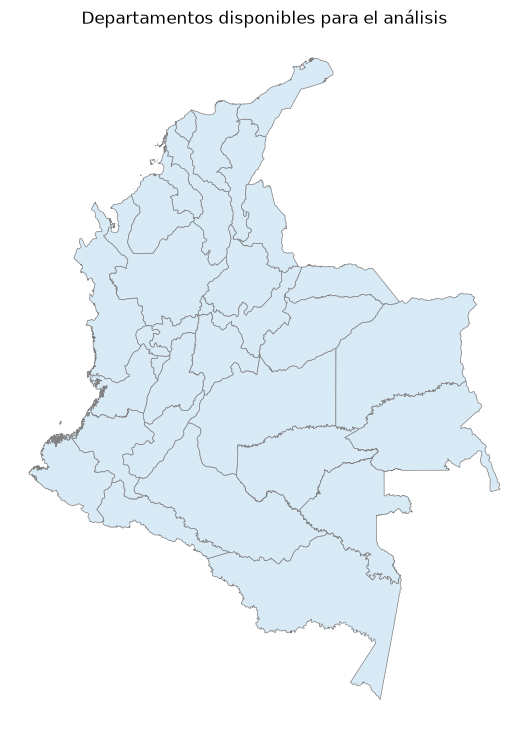

In [18]:
fig, ax = plt.subplots(figsize=(8, 9))
colombia_9377.plot(
    ax=ax,
    color="#d9eaf7",
    edgecolor="grey",
    linewidth=0.5
)
ax.set_title("Departamentos disponibles para el análisis")
ax.set_xlim(*x_limits)
ax.set_ylim(*y_limits)
ax.set_axis_off()
plt.show()

# 1. Mapa de densidad de puntos

En un DDM todos los puntos tienen el mismo tamaño y el mismo valor. Aquí cada punto representa aproximadamente cinco homicidios registrados. Cuando el valor no es múltiplo de cinco, el número de puntos se redondea y se garantiza al menos uno para no hacer desaparecer a los departamentos con valores pequeños.

Los puntos se distribuyen aleatoriamente dentro de cada polígono. No indican el lugar exacto donde ocurrió un hecho; solo representan la cantidad departamental.

In [19]:
dot_map = colombia_9377.copy()
dot_value = 5

dot_map["num_dots"] = np.maximum(
    1,
    np.rint(dot_map["homicidios_2025"] / dot_value).astype(int)
)

dot_map[
    ["departamento", "homicidios_2025", "num_dots"]
].sort_values("homicidios_2025", ascending=False).head(10)

,departamento,homicidios_2025,num_dots
28,Valle del Cauca,3074,615
1,Antioquia,2980,596
21,Norte de Santander,1168,234
3,Atlántico,1113,223
9,Cauca,1110,222
13,Cundinamarca,1010,202
4,Bolívar,1000,200
25,Santander,895,179
18,Magdalena,801,160
16,Huila,730,146


In [20]:
sampled_points = dot_map.geometry.sample_points(
    size=dot_map["num_dots"],
    rng=12345
)

homicide_dots = gpd.GeoDataFrame(
    geometry=sampled_points.explode(index_parts=False).reset_index(drop=True),
    crs=colombia_9377.crs
)

print("Puntos representados:", len(homicide_dots))

Puntos representados: 3950


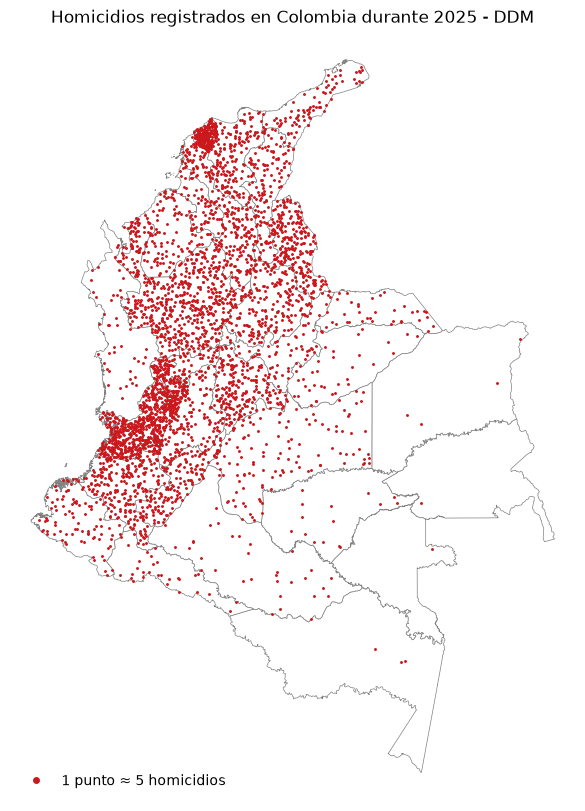

In [21]:
fig, ax = plt.subplots(figsize=(9, 10))

colombia_9377.plot(
    ax=ax,
    facecolor="white",
    edgecolor="grey",
    linewidth=0.5
)
homicide_dots.plot(
    ax=ax,
    markersize=1.2,
    color="#cb181d"
)

dot_legend = Line2D(
    [0], [0],
    marker="o",
    color="none",
    markerfacecolor="#cb181d",
    markeredgecolor="none",
    markersize=5,
    label="1 punto ≈ 5 homicidios"
)

ax.legend(handles=[dot_legend], loc="lower left", frameon=False)
ax.set_title("Homicidios registrados en Colombia durante 2025 - DDM")
ax.set_xlim(*x_limits)
ax.set_ylim(*y_limits)
ax.set_axis_off()
plt.show()

El DDM permite reconocer dónde se concentra una mayor parte del total registrado. Los departamentos con más puntos dominan la imagen, pero esto todavía no significa que tengan una mayor intensidad relativa: también suelen concentrar más población.

# 2. Mapa de símbolos proporcionales

El PSM representa nuevamente los valores absolutos, pero utiliza un círculo por departamento. La posición se obtiene con `representative_point()`, que mantiene el símbolo dentro de su geometría. La raíz cuadrada comprime la diferencia visual entre valores muy altos y bajos, siguiendo el criterio utilizado en la evaluación individual.

In [22]:
symbol_map = colombia_9377.copy()
symbol_map["geometry"] = symbol_map.representative_point()

symbol_scale = 6
symbol_map["size"] = (
    np.sqrt(symbol_map["homicidios_2025"]) * symbol_scale
)

symbol_map[
    ["departamento", "homicidios_2025", "size"]
].sort_values("homicidios_2025", ascending=False).head(10)

,departamento,homicidios_2025,size
28,Valle del Cauca,3074,332.661991
1,Antioquia,2980,327.536258
21,Norte de Santander,1168,205.056090
3,Atlántico,1113,200.169928
9,Cauca,1110,199.899975
13,Cundinamarca,1010,190.682983
4,Bolívar,1000,189.736660
25,Santander,895,179.499304
18,Magdalena,801,169.811660
16,Huila,730,162.111073


Antes de dibujar el PSM se identifican los valores atípicos con el criterio intercuartílico. Un valor se considera atípico superior cuando supera $Q_3 + 1.5\,IQR$. Esta revisión se calcula directamente sobre los datos y no depende del gráfico.

In [23]:
q1 = symbol_map["homicidios_2025"].quantile(0.25)
q3 = symbol_map["homicidios_2025"].quantile(0.75)
iqr = q3 - q1
lower_limit = q1 - 1.5 * iqr
upper_limit = q3 + 1.5 * iqr

symbol_map["es_atipico"] = ~symbol_map["homicidios_2025"].between(
    lower_limit,
    upper_limit
)

symbol_map[
    symbol_map["es_atipico"]
][["departamento", "homicidios_2025"]].sort_values(
    "homicidios_2025",
    ascending=False
)

,departamento,homicidios_2025
28,Valle del Cauca,3074
1,Antioquia,2980


C:\Users\Strix\AppData\Local\Temp\ipykernel_31832\4232246231.py:2: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax.boxplot(


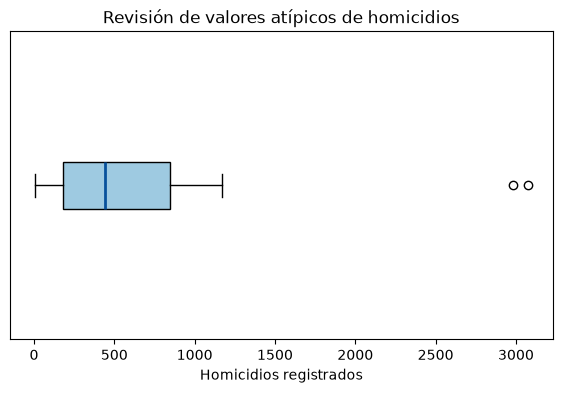

In [24]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.boxplot(
    colombia_9377["homicidios_2025"],
    vert=False,
    patch_artist=True,
    boxprops={"facecolor": "#9ecae1"},
    medianprops={"color": "#08519c", "linewidth": 2}
)
ax.set_title("Revisión de valores atípicos de homicidios")
ax.set_xlabel("Homicidios registrados")
ax.set_yticks([])
plt.show()

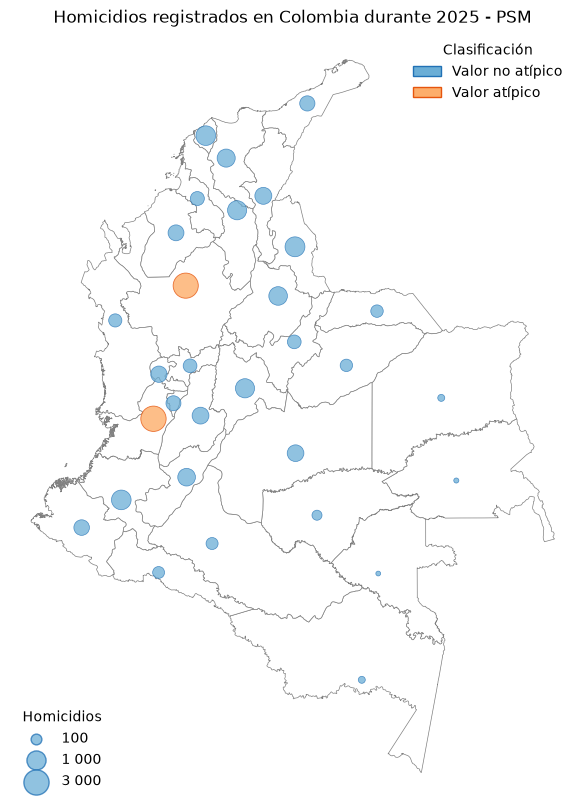

In [25]:
symbols_regular = symbol_map[~symbol_map["es_atipico"]].copy()
symbols_outlier = symbol_map[symbol_map["es_atipico"]].copy()

fig, ax = plt.subplots(figsize=(9, 10))

colombia_9377.plot(
    ax=ax,
    color="white",
    edgecolor="grey",
    linewidth=0.5
)
symbols_regular.plot(
    ax=ax,
    markersize=symbols_regular["size"],
    color="#6baed6",
    edgecolor="#2171b5",
    linewidth=0.5,
    alpha=0.75
)
symbols_outlier.plot(
    ax=ax,
    markersize=symbols_outlier["size"],
    color="#fdae6b",
    edgecolor="#e6550d",
    linewidth=0.6,
    alpha=0.80
)

size_values = [100, 1_000, 3_000]
size_handles = [
    ax.scatter(
        [], [],
        s=np.sqrt(value) * symbol_scale,
        facecolor="#6baed6",
        edgecolor="#2171b5",
        alpha=0.75,
        label=f"{value:,}".replace(",", " ")
    )
    for value in size_values
]

size_legend = ax.legend(
    handles=size_handles,
    title="Homicidios",
    loc="lower left",
    frameon=False
)
ax.add_artist(size_legend)

color_handles = [
    Patch(facecolor="#6baed6", edgecolor="#2171b5", label="Valor no atípico"),
    Patch(facecolor="#fdae6b", edgecolor="#e6550d", label="Valor atípico")
]
ax.legend(
    handles=color_handles,
    title="Clasificación",
    loc="upper right",
    frameon=False
)

ax.set_title("Homicidios registrados en Colombia durante 2025 - PSM")
ax.set_xlim(*x_limits)
ax.set_ylim(*y_limits)
ax.set_axis_off()
plt.show()

El PSM facilita la comparación entre departamentos porque cada unidad tiene un solo símbolo. Los círculos naranjas indican valores que se apartan claramente del conjunto. Igual que el DDM, este mapa presenta cantidades totales y todavía está influido por el tamaño de la población.

# 3. Mapa coroplético

Una coropleta con el número bruto de homicidios podría sugerir mayor intensidad únicamente porque un departamento tiene más habitantes. Por ello se calcula una tasa por cada 100 000 habitantes:

$$
\text{Tasa de homicidios}
= \frac{\text{homicidios registrados}}{\text{población proyectada}}\times 100\,000
$$

La tasa permite comparar departamentos con tamaños poblacionales diferentes. No debe interpretarse como una tasa exclusiva de violencia intencional porque el CSV también incluye homicidios por tránsito.

In [26]:
colombia_9377["tasa_homicidios_100000"] = (
    colombia_9377["homicidios_2025"]
    / colombia_9377["poblacion_2025"]
    * 100_000
)

colombia_9377[
    [
        "departamento",
        "homicidios_2025",
        "poblacion_2025",
        "tasa_homicidios_100000"
    ]
].sort_values(
    "tasa_homicidios_100000",
    ascending=False
).head(10)

,departamento,homicidios_2025,poblacion_2025,tasa_homicidios_100000
15,Guaviare,76,84696,89.732691
9,Cauca,1110,1599148,69.411962
21,Norte de Santander,1168,1709289,68.332506
23,Quindío,377,557884,67.576772
28,Valle del Cauca,3074,4708393,65.287668
2,Arauca,182,279191,65.188348
16,Huila,730,1208728,60.394067
24,Risaralda,532,1003225,53.028982
18,Magdalena,801,1544507,51.861209
19,Meta,581,1156405,50.241914


### Cómo se forman las clases

La tasa es una variable continua y se agrupa en cinco clases. Se comparan seis métodos que producen cinco grupos mediante la desviación absoluta alrededor de la mediana de cada clase (ADCM). Un ADCM menor indica que los valores reunidos dentro de cada clase son más semejantes.

A diferencia de seleccionar un método por costumbre, el código elige el menor ADCM obtenido con estos datos.

In [27]:
np.random.seed(12345)

K = 5
the_variable = colombia_9377["tasa_homicidios_100000"]

classifiers = [
    mapclassify.EqualInterval(the_variable, k=K),
    mapclassify.Quantiles(the_variable, k=K),
    mapclassify.MaximumBreaks(the_variable, k=K),
    mapclassify.FisherJenks(the_variable, k=K),
    mapclassify.JenksCaspall(the_variable, k=K),
    mapclassify.MaxP(the_variable, k=K)
]

adcm_comparison = pd.DataFrame({
    "Clasificador": [classifier.name for classifier in classifiers],
    "ADCM": [classifier.adcm for classifier in classifiers]
}).sort_values("ADCM").reset_index(drop=True)

adcm_comparison

d:\Python\.venv\Lib\site-packages\IPython\core\interactiveshell.py:3748: UserWarning: Numba not installed. Using slow pure python version.
  exec(code_obj, self.user_global_ns, self.user_ns)


,Clasificador,ADCM
0,JenksCaspall,83.872116
1,FisherJenks,97.721395
2,MaximumBreaks,97.721395
3,EqualInterval,123.960102
4,MaxP,126.586811
5,Quantiles,136.428972


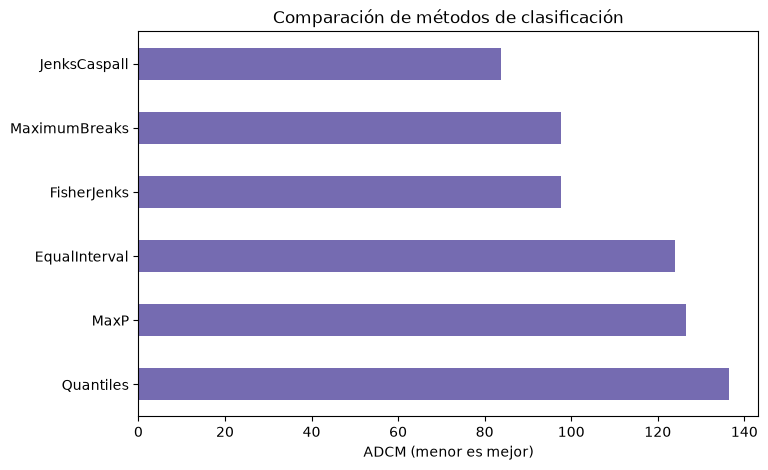

In [28]:
adcm_comparison.sort_values("ADCM", ascending=False).plot.barh(
    x="Clasificador",
    y="ADCM",
    legend=False,
    color="#756bb1",
    figsize=(8, 5)
)
plt.title("Comparación de métodos de clasificación")
plt.xlabel("ADCM (menor es mejor)")
plt.ylabel("")
plt.show()

In [29]:
selected_classifier = min(
    classifiers,
    key=lambda classifier: classifier.adcm
)

selected_name = selected_classifier.name
print("Clasificador seleccionado:", selected_name)
print("ADCM:", round(selected_classifier.adcm, 4))

colombia_9377["clase_codigo"] = selected_classifier.yb

level_labels = {
    0: "Muy bajo",
    1: "Bajo",
    2: "Medio",
    3: "Alto",
    4: "Muy alto"
}
ordered_labels = [level_labels[i] for i in range(K)]

colombia_9377["clase_tasa"] = pd.Categorical(
    colombia_9377["clase_codigo"].replace(level_labels),
    categories=ordered_labels,
    ordered=True
)

class_limits = pd.DataFrame({
    "Clase": ordered_labels,
    "Límite_superior": np.round(selected_classifier.bins, 2)
})

class_limits

Clasificador seleccionado: JenksCaspall
ADCM: 83.8721


,Clase,Límite_superior
0,Muy bajo,12.10
1,Bajo,28.57
2,Medio,44.62
3,Alto,53.03
4,Muy alto,89.73


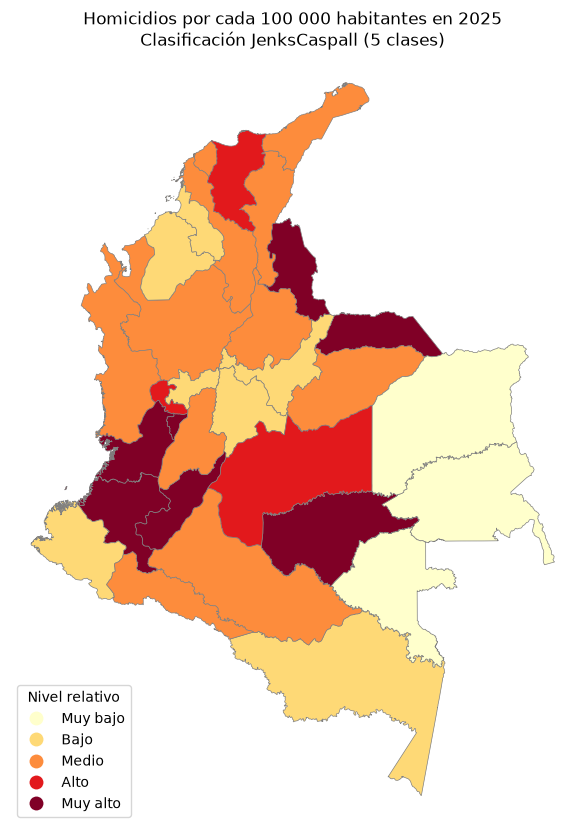

In [30]:
fig, ax = plt.subplots(figsize=(9, 10))

colombia_9377.plot(
    column="clase_tasa",
    cmap="YlOrRd",
    categorical=True,
    edgecolor="grey",
    linewidth=0.5,
    legend=True,
    legend_kwds={
        "title": "Nivel relativo",
        "loc": "lower left"
    },
    ax=ax
)

ax.set_title(
    "Homicidios por cada 100 000 habitantes en 2025\n"
    f"Clasificación {selected_name} ({K} clases)"
)
ax.set_xlim(*x_limits)
ax.set_ylim(*y_limits)
ax.set_axis_off()
plt.show()

## Lectura conjunta

Los tres mapas no son versiones intercambiables. El DDM y el PSM resaltan los departamentos que concentran una mayor cantidad total de homicidios registrados. Por ello, una unidad muy poblada puede destacar aunque su intensidad relativa no sea la más alta.

La coropleta relaciona los registros con la población y permite comparar departamentos de tamaños distintos. Esto explica por qué un departamento puede tener pocos puntos o un círculo pequeño y, al mismo tiempo, aparecer en una categoría alta: el número absoluto es reducido, pero resulta elevado en relación con sus habitantes.

    La interpretación final debe conservar dos límites. Primero, la variable utilizada combina homicidio intencional y homicidio por tránsito vehicular. Segundo, el GeoPackage disponible no identifica las geometrías de Bogotá ni San Andrés y Providencia; por tanto, los mapas actuales representan 31 unidades y no deben presentarse como una cobertura espacial completa de las 33 unidades incluidas en los CSV.